In [1]:
%matplotlib widget

import tqdm
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

from bscarlos.settings import RAW_KISPI_DATA_FOLDER
from bscarlos.settings import PROCESSED_KISPI_DATA_FOLDER
from bscarlos.detector import ClusteringDetector
from bscarlos.detector_v3 import ClusteringDetector_v3

# KISPI (1) Validation
This notebook contains the code and ending results of running BSUPP algorithm on ONE patient from Kinderspital.  

The objective is to get the algorithm to detect burst on KISPI-EEG data for one patient.

Essentially breaking down the problem of validating the algorithm on all patients using a step-wise approach. 

In [2]:
data_attributes = pd.read_csv(PROCESSED_KISPI_DATA_FOLDER / 'data_attributes_kispi.csv').set_index("patient_id")
data_attributes

,unique_patient_id,start_datetime,end_sample,sample_rate
patient_id,,,,
P1,SE008_ant1,2012-04-17 17:02:08,2012-04-18 09:19:22.996093,256.0
P2,SE021_ant1,2015-09-01 16:06:27,2015-09-01 16:30:26.996093,256.0
P3,SE021_ant2,2015-09-01 16:06:27,2015-09-01 16:30:26.996093,256.0
P4,SE026_ant1,2014-05-20 08:30:52,2014-05-20 09:40:12.996093,256.0
P5,SE038_ant1,2018-05-23 11:05:57,2018-05-23 12:50:31.996093,256.0
P6,SE038_ant2,2018-05-23 11:05:57,2018-05-23 12:50:31.996093,256.0


Check `sample_rate` frequency

In [3]:
print(data_attributes['sample_rate'])

patient_id
P1    256.0
P2    256.0
P3    256.0
P4    256.0
P5    256.0
P6    256.0
Name: sample_rate, dtype: float64


In [4]:
patient01_data_attributes = data_attributes.iloc[0]

## Load Data Files

In [5]:
data_files = sorted(list(PROCESSED_KISPI_DATA_FOLDER.glob('*.parquet')))
print(data_files)

[WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/processed_kispi/SE008_a1.parquet'), WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/processed_kispi/SE021_a1.parquet'), WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/processed_kispi/SE021_a2.parquet'), WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/processed_kispi/SE026_a1.parquet'), WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/processed_kispi/SE038_a1.parquet'), WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/processed_kispi/SE038_a2.parquet')]


In [6]:
pfile = pq.read_table(data_files[0])
print("Column names: {}".format(pfile.column_names))
print("Schema: {}".format(pfile.schema))

Column names: ['EEG Fp1', 'EEG Fp2', 'EEG F7', 'EEG F3', 'EEG Fz', 'EEG F4', 'EEG F8', 'EEG T3', 'EEG C3', 'EEG Cz', 'EEG C4', 'EEG T4', 'EEG T5', 'EEG P3', 'EEG Pz', 'EEG P4', 'EEG T6', 'EEG O1', 'EEG O2', '__index_level_0__']
Schema: EEG Fp1: float
  -- field metadata --
  edf_signal_header: '{"label": "EEG Fp1", "dimension": "uV", "sample_rat' + 210
EEG Fp2: float
  -- field metadata --
  edf_signal_header: '{"label": "EEG Fp2", "dimension": "uV", "sample_rat' + 210
EEG F7: float
  -- field metadata --
  edf_signal_header: '{"label": "EEG F7", "dimension": "uV", "sample_rate' + 209
EEG F3: float
  -- field metadata --
  edf_signal_header: '{"label": "EEG F3", "dimension": "uV", "sample_rate' + 209
EEG Fz: float
  -- field metadata --
  edf_signal_header: '{"label": "EEG Fz", "dimension": "uV", "sample_rate' + 209
EEG F4: float
  -- field metadata --
  edf_signal_header: '{"label": "EEG F4", "dimension": "uV", "sample_rate' + 209
EEG F8: float
  -- field metadata --
  edf_signal_head

### Create `patient_data` dataframe
store all relavant information for BSUPP Algorithm

In [7]:
patient01_data = pd.read_parquet(data_files[0])
patient01_data.head()

,EEG Fp1,EEG Fp2,EEG F7,EEG F3,EEG Fz,EEG F4,EEG F8,EEG T3,EEG C3,EEG Cz,EEG C4,EEG T4,EEG T5,EEG P3,EEG Pz,EEG P4,EEG T6,EEG O1,EEG O2
2012-04-17 17:02:08.000000,107.303505,78.486382,163.326843,136.478592,-6.354085,123.591438,143.638138,102.649803,41.435799,84.392998,104.797668,-5.280156,121.980545,138.805450,73.116730,30.338522,-16.377432,63.988327,160.463028
2012-04-17 17:02:08.003906,107.303505,78.665367,164.400772,136.120621,-6.354085,121.622566,142.922180,101.217896,39.466927,81.350197,102.470818,-6.175097,119.653694,135.225677,70.073929,28.011673,-17.451363,61.482491,157.062256
2012-04-17 17:02:08.007812,108.914398,80.634239,167.980545,138.626465,-5.996109,123.412453,145.428009,103.723732,39.824902,81.887161,104.081711,-4.922179,118.937744,135.762650,71.147858,28.190662,-15.124514,59.513618,158.136185
2012-04-17 17:02:08.011718,108.914398,80.992218,167.443573,138.805450,-5.459144,123.591438,146.143967,102.470818,39.108948,82.424126,105.871597,-3.490272,118.400780,136.120621,73.116730,30.159533,-13.513618,58.439690,159.568100
2012-04-17 17:02:08.015625,108.556419,81.529182,166.727631,137.552536,-3.311284,124.486382,145.964981,101.575874,38.929962,84.392998,107.661476,-1.342412,120.190659,137.731522,75.622566,32.844357,-11.723736,60.229572,162.073929


### Create Ground Truth labels from annotations

In [8]:
annotations_df = pd.read_csv(RAW_KISPI_DATA_FOLDER / "SE008_annotated1_annotations.txt")
annotations_df.head()

,Onset,Duration,Annotation
0,2012-04-17T17:02:12.5802030,NaN,Burst starts
1,2012-04-17T17:02:13.2416306,NaN,Burst end
2,2012-04-17T17:02:55.9220000,NaN,Burst starts
3,2012-04-17T17:02:57.5790000,NaN,Burst end
4,2012-04-17T17:03:00.5140000,NaN,Burst starts


Create a new `annotations_df` and itterate over annotations to create a `ground_truth_df`

In [9]:
annotations_df["Onset"] = pd.to_datetime(annotations_df["Onset"], format="%Y-%m-%dT%H:%M:%S.%f")

patient01_timestamps = patient01_data.index
ground_truth_df = pd.DataFrame(
    {"timestamp" : patient01_timestamps, "ground_truth" : 0}
    )

ground_truth_df["timestamp"] = pd.to_datetime(ground_truth_df["timestamp"], format="%Y-%m-%dT%H:%M:%S.%f")

for index, row in annotations_df.iterrows():
    if row["Annotation"] == "Burst starts":
        start_time = row["Onset"]
        end_time = annotations_df.loc[index + 1, "Onset"]

        ground_truth_df.loc[
            (ground_truth_df["timestamp"] >= start_time) 
            & (ground_truth_df["timestamp"] <= end_time), 
            "ground_truth",] = 1

In [10]:
ground_truth_df.head(-1)

,timestamp,ground_truth
0,2012-04-17 17:02:08.000000,0
1,2012-04-17 17:02:08.003906,0
2,2012-04-17 17:02:08.007812,0
3,2012-04-17 17:02:08.011718,0
4,2012-04-17 17:02:08.015625,0
...,...,...
15010554,2012-04-18 09:19:22.976562,0
15010555,2012-04-18 09:19:22.980468,0
15010556,2012-04-18 09:19:22.984375,0
15010557,2012-04-18 09:19:22.988281,0


Merge the 'ground_truth' column with the `patient01_data`

In [ ]:
patient01_data = pd.merge(
    patient01_data, ground_truth_df, left_index=True, right_on="timestamp"
)

In [12]:
patient01_data.head(-1)

,EEG Fp1,EEG Fp2,EEG F7,EEG F3,EEG Fz,EEG F4,EEG F8,EEG T3,EEG C3,EEG Cz,...,EEG T4,EEG T5,EEG P3,EEG Pz,EEG P4,EEG T6,EEG O1,EEG O2,timestamp,ground_truth
0,107.303505,78.486382,163.326843,136.478592,-6.354085,123.591438,143.638138,102.649803,41.435799,84.392998,...,-5.280156,121.980545,138.805450,73.116730,30.338522,-16.377432,63.988327,160.463028,2012-04-17 17:02:08.000000,0
1,107.303505,78.665367,164.400772,136.120621,-6.354085,121.622566,142.922180,101.217896,39.466927,81.350197,...,-6.175097,119.653694,135.225677,70.073929,28.011673,-17.451363,61.482491,157.062256,2012-04-17 17:02:08.003906,0
2,108.914398,80.634239,167.980545,138.626465,-5.996109,123.412453,145.428009,103.723732,39.824902,81.887161,...,-4.922179,118.937744,135.762650,71.147858,28.190662,-15.124514,59.513618,158.136185,2012-04-17 17:02:08.007812,0
3,108.914398,80.992218,167.443573,138.805450,-5.459144,123.591438,146.143967,102.470818,39.108948,82.424126,...,-3.490272,118.400780,136.120621,73.116730,30.159533,-13.513618,58.439690,159.568100,2012-04-17 17:02:08.011718,0
4,108.556419,81.529182,166.727631,137.552536,-3.311284,124.486382,145.964981,101.575874,38.929962,84.392998,...,-1.342412,120.190659,137.731522,75.622566,32.844357,-11.723736,60.229572,162.073929,2012-04-17 17:02:08.015625,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15010554,116.789886,45.552528,300.252930,105.334633,-1.521401,108.198441,-1210.766479,138.626465,104.439690,6.712062,...,31.054474,-34.813229,28.011673,-100.143967,24.610895,57.902725,-674.159546,122.696495,2012-04-18 09:19:22.976562,0
15010555,115.715950,45.015564,298.105072,110.883270,46.089493,108.377434,-1048.424072,135.762650,101.038910,4.385214,...,32.307392,-36.603111,26.579767,-102.291832,23.357977,56.649807,-674.338501,121.264595,2012-04-18 09:19:22.980468,0
15010556,117.147858,45.015564,299.357971,126.276268,110.167313,105.155640,-741.101196,131.108948,98.712059,5.996109,...,31.054474,-36.424126,25.684824,-103.723732,21.389105,57.723736,-672.727600,118.758759,2012-04-18 09:19:22.984375,0
15010557,118.937744,47.521400,301.147858,122.338524,62.556419,105.692604,-670.221802,135.404663,98.712059,3.848249,...,32.665371,-34.455254,24.252918,-104.439690,19.599222,57.902725,-674.159546,117.505836,2012-04-18 09:19:22.988281,0


Before we create our patient dictionary we need to create bipolar channel pairs.

As this is the standard way EEG chanels are formated when specialists read and interrept the EEG.

This also limits the redundancy of the current channel label format ie. (EEG Fp1, EEG Fp2, etc.)

In [13]:
def create_bipolar_channels(df):
  """
  Creates bipolar channels from the original channels.

  Args:
    df: A Pandas DataFrame with the EEG data, where the index is a datetime object.

  Returns:
    A DataFrame with bipolar channels.
  """

  # create list of bipolar pairs
  # list is derived from ACNS standardized longitudinal bipolar montage[1]
  # [1]: https://www.acns.org/UserFiles/file/EEGGuideline3Montage.pdf
  bipolar_pairs = [
      ('Fp1-F7', 'EEG Fp1', 'EEG F7'),
      ('F7-T3', 'EEG F7', 'EEG T3'),
      ('T3-T5', 'EEG T3', 'EEG T5'),
      ('Fp1-F3', 'EEG Fp1', 'EEG F3'),
      ('F3-C3', 'EEG F3', 'EEG C3'),
      ('C3-P3', 'EEG C3', 'EEG P3'),
      ('P3-O1', 'EEG P3', 'EEG O1'),
      ('Fz-Cz', 'EEG Fz', 'EEG Cz'),
      ('Cz-Pz', 'EEG Cz', 'EEG Pz'),
      ('Fp2-F4', 'EEG Fp2', 'EEG F4'),
      ('F4-C4', 'EEG F4', 'EEG C4'),
      ('C4-P4', 'EEG C4', 'EEG P4'),
      ('P4-O2', 'EEG P4', 'EEG O2'),
      ('Fp2-F8', 'EEG Fp2', 'EEG F8'),
      ('F8-T4', 'EEG F8', 'EEG T4'),
      ('T4-T6', 'EEG T4', 'EEG T6'),
      ('T6-O2', 'EEG T6', 'EEG O2'),
  ]

  # create a new empty DataFrame
  bipolar_df = pd.DataFrame(index=df.index)

  for pair in bipolar_pairs:
      # strip any leading/trailing spaces from column names
      ch1 = pair[1].strip()  
      ch2 = pair[2].strip()

      if ch1 in df.columns and ch2 in df.columns:
          bipolar_df[pair[0]] = df[ch1] - df[ch2]
      else:
          print(f"Warning: Channel(s) missing for pair {pair[0]}")

  return bipolar_df

We first convert the `patient01_data` into a pandas data frame.

Then apply our `create_bipolar_channels` function to convert the column names.

In [14]:
patient01_df = pd.DataFrame(patient01_data.copy()).reset_index()

print(patient01_df.head(-1))

             index     EEG Fp1    EEG Fp2      EEG F7      EEG F3      EEG Fz  \
0                0  107.303505  78.486382  163.326843  136.478592   -6.354085   
1                1  107.303505  78.665367  164.400772  136.120621   -6.354085   
2                2  108.914398  80.634239  167.980545  138.626465   -5.996109   
3                3  108.914398  80.992218  167.443573  138.805450   -5.459144   
4                4  108.556419  81.529182  166.727631  137.552536   -3.311284   
...            ...         ...        ...         ...         ...         ...   
15010554  15010554  116.789886  45.552528  300.252930  105.334633   -1.521401   
15010555  15010555  115.715950  45.015564  298.105072  110.883270   46.089493   
15010556  15010556  117.147858  45.015564  299.357971  126.276268  110.167313   
15010557  15010557  118.937744  47.521400  301.147858  122.338524   62.556419   
15010558  15010558  117.684822  50.743191  300.968872  102.291832  -23.894941   

              EEG F4       

In [15]:
bipolar_patient01_df = create_bipolar_channels(patient01_df)

print(bipolar_patient01_df.head(-1))

              Fp1-F7       F7-T3       T3-T5     Fp1-F3      F3-C3      C3-P3  \
0         -56.023338   60.677040  -19.330742 -29.175087  95.042793 -97.369652   
1         -57.097267   63.182877  -18.435799 -28.817116  96.653694 -95.758751   
2         -59.066147   64.256813  -15.214012 -29.712067  98.801559 -95.937744   
3         -58.529175   64.972755  -15.929962 -29.891052  99.696503 -97.011673   
4         -58.171211   65.151756  -18.614784 -28.996117  98.622574 -98.801559   
...              ...         ...         ...        ...        ...        ...   
15010554 -183.463043  161.626465  173.439697  11.455254   0.894943  76.428017   
15010555 -182.389130  162.342422  172.365753   4.832680   9.844360  74.459145   
15010556 -182.210114  168.249023  167.533081  -9.128410  27.564209  73.027237   
15010557 -182.210114  165.743195  169.859924  -3.400780  23.626465  74.459137   
15010558 -183.284058  165.027237  170.396881  15.392990   3.221794  77.143967   

               P3-O1       

Create a new `annotations_df` and itterate over annotations to create a `ground_truth_df`

Merge the 'ground_truth' column with the `patient01_data`

In [16]:
patient01_data.shape

(15010560, 21)

Now we can work with the patient data frame with bipolar channels directly

## Create Learning and Testing Data
Seprating data based on:
- Learning period == First 15min Window
- Testing period >= 15min

In [17]:
fs = 256
learning_period_s = 60*15 
data_learning = bipolar_patient01_df.iloc[0:fs*learning_period_s]
data_learning.index = data_learning.index*pd.Timedelta(1/fs, 's')
data_testing = bipolar_patient01_df.iloc[fs*learning_period_s:]
data_testing.index = data_testing.index*pd.Timedelta(1/fs, 's')

In [18]:
print(data_learning.head(-1))
print(data_learning.shape)

                              Fp1-F7      F7-T3      T3-T5     Fp1-F3  \
0 days 00:00:00           -56.023338  60.677040 -19.330742 -29.175087   
0 days 00:00:00.003906250 -57.097267  63.182877 -18.435799 -28.817116   
0 days 00:00:00.007812500 -59.066147  64.256813 -15.214012 -29.712067   
0 days 00:00:00.011718750 -58.529175  64.972755 -15.929962 -29.891052   
0 days 00:00:00.015625    -58.171211  65.151756 -18.614784 -28.996117   
...                              ...        ...        ...        ...   
0 days 00:14:59.976562500 -65.509735  93.789894  25.774315  -4.295723   
0 days 00:14:59.980468750 -66.762650  91.642029  25.058365  -6.622566   
0 days 00:14:59.984375    -69.089493  91.284050  25.416340 -10.202332   
0 days 00:14:59.988281250 -71.953308  89.852142  26.669262 -14.856026   
0 days 00:14:59.992187500 -70.700394  88.778214  28.996105 -17.898834   

                                F3-C3      C3-P3      P3-O1      Fz-Cz  \
0 days 00:00:00             95.042793 -97.369652 

In [19]:
print(data_testing.head(-1))
print(data_testing.shape)

                               Fp1-F7       F7-T3       T3-T5     Fp1-F3  \
0 days 00:15:00            -67.478592   86.093376   33.828796 -18.435799   
0 days 00:15:00.003906250  -63.719849   92.000000   33.470818 -15.929962   
0 days 00:15:00.007812500  -61.035011  100.233459   27.743191 -13.603111   
0 days 00:15:00.011718750  -60.140076   95.758759   33.470814 -11.992218   
0 days 00:15:00.015625     -56.739304   93.073929   35.260704  -8.233467   
...                               ...         ...         ...        ...   
0 days 16:17:14.976562500 -183.463043  161.626465  173.439697  11.455254   
0 days 16:17:14.980468750 -182.389130  162.342422  172.365753   4.832680   
0 days 16:17:14.984375    -182.210114  168.249023  167.533081  -9.128410   
0 days 16:17:14.988281250 -182.210114  165.743195  169.859924  -3.400780   
0 days 16:17:14.992187500 -183.284058  165.027237  170.396881  15.392990   

                                F3-C3      C3-P3       P3-O1       Fz-Cz  \
0 days 00:1

### Plot Learning and Testing Data

In [20]:
def plot_eeg_multiple(df):
    n_samples = len(df.index)
    data = df.to_numpy().T
    
    # extract the total seconds
    t_s = (df.index - df.index[0]).total_seconds()

    five_min = next((i for i, t in enumerate(t_s) if t > 300), n_samples)

    plt.figure(figsize=(12, 8)) 

    for i, col in enumerate(df):
        x = data[i]
        plt.plot(t_s[:five_min], x[:five_min] + 100*i, label=col)

    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (with offset)')
    plt.title('EEG Time Series Data (First 5 minutes)')
    plt.legend(loc='upper right', bbox_to_anchor=(1, 1), ncol=4)
    plt.tight_layout()
    plt.show()

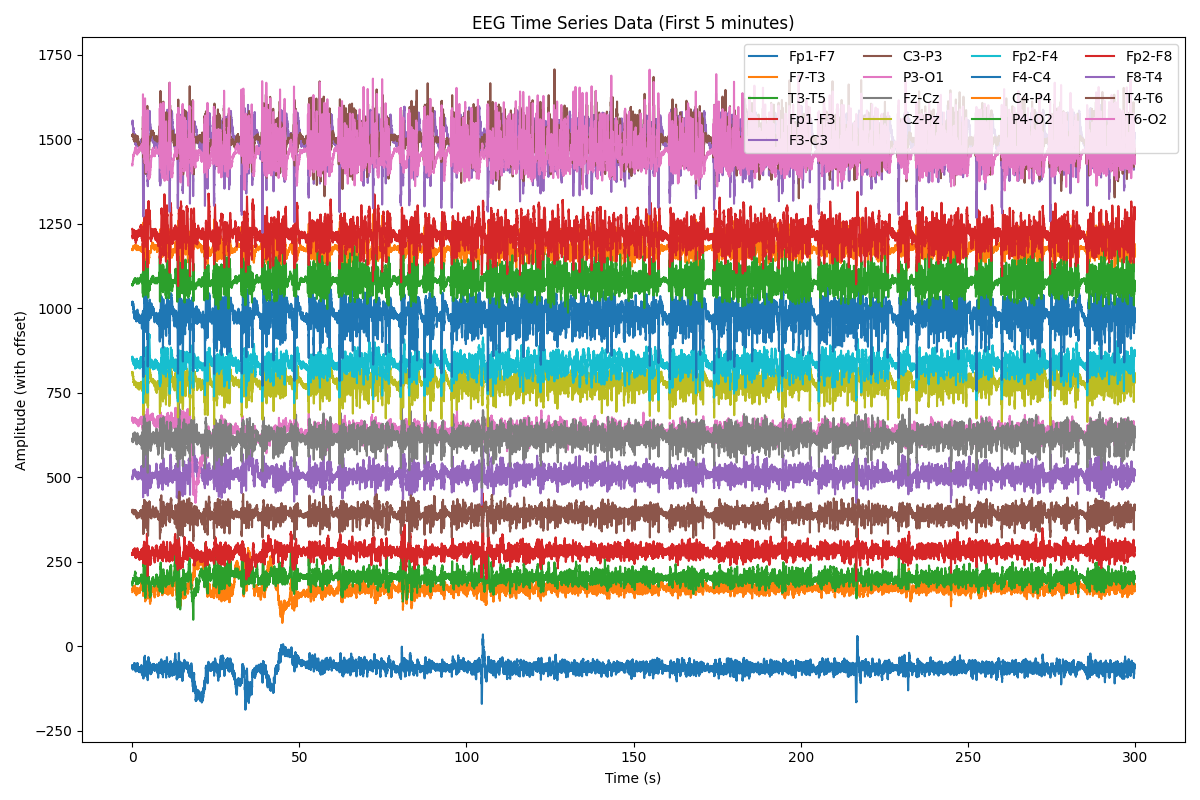

In [21]:
plot_eeg_multiple(data_learning)

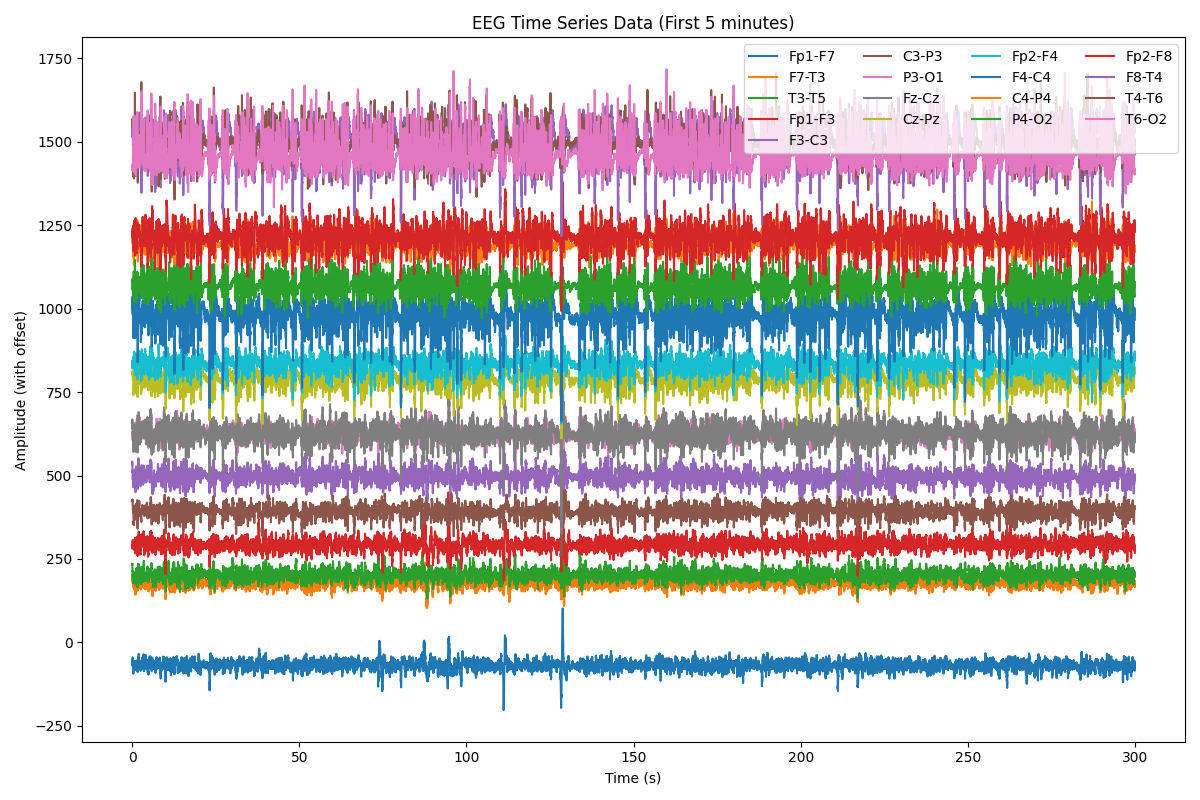

In [22]:
plot_eeg_multiple(data_testing)

In [23]:
import pandas as pd
import altair as alt

df_learning = data_learning.copy()

# Convert the DatetimeIndex to total seconds
df_learning['time_seconds'] = df_learning.index.total_seconds()

# Melt the DataFrame to long format
df_melted = data_learning.melt(id_vars='time_seconds', var_name='Channel', value_name='Amplitude')

# Create the base chart
base = alt.Chart(df_melted).encode(
    x=alt.X('time_seconds', title='Time (seconds)'),
    y=alt.Y('Amplitude', title='Amplitude'),
    color='Channel',
    tooltip=['time_seconds', 'Channel', 'Amplitude']
)

# Add a selection for the scrolling window
brush = alt.selection_interval(encodings=['x'])

# Create the line chart with the selection
lines = base.mark_line().encode(
    opacity=alt.condition(brush, alt.value(1), alt.value(0.2))
)

# Create the selection window (mini-chart)
mini_chart = base.mark_line().add_params(brush).properties(
    height=60
)

# Combine the main chart and the mini-chart
chart = alt.vconcat(lines, mini_chart).properties(
    title='EEG Time Series Data with Scrolling Window'
)

# Make the chart interactive
chart = chart.interactive()

# Save the chart
chart.save('eeg_scrolling_plot.html')

KeyError: "The following id_vars or value_vars are not present in the DataFrame: ['time_seconds']"

### Create EEG-only Data 
(SKIP THIS FOR NOW STILL WAITING ON GROUND TRUTH LABELS FROM ANNOTATORS)

Dropping 'ground_truth' column from learning and testing datasets


In [ ]:
#eeg_cols = [str(i) for i in range(18)]

In [ ]:
# separate eeg
eeg_learning = data_learning.copy()#[eeg_cols]
eeg_learning.head(-1)

,Fp1-F7,F7-T3,T3-T5,Fp1-F3,F3-C3,C3-P3,P3-O1,Fz-Cz,Cz-Pz,Fp2-F4,F4-C4,C4-P4,P4-O2,Fp2-F8,F8-T4,T4-T6,T6-O2
0 days 00:00:00,-56.023338,60.677040,-19.330742,-29.175087,95.042793,-97.369652,74.817123,-90.747086,11.276268,-45.105057,18.793770,74.459145,-130.124512,-65.151756,148.918289,11.097277,-176.840454
0 days 00:00:00.003906250,-57.097267,63.182877,-18.435799,-28.817116,96.653694,-95.758751,73.743187,-87.704285,11.276268,-42.957199,19.151749,74.459145,-129.050583,-64.256813,149.097275,11.276265,-174.513611
0 days 00:00:00.007812500,-59.066147,64.256813,-15.214012,-29.712067,98.801559,-95.937744,76.249031,-87.883270,10.739304,-42.778214,19.330742,75.891052,-129.945526,-64.793770,150.350189,10.202334,-173.260696
0 days 00:00:00.011718750,-58.529175,64.972755,-15.929962,-29.891052,99.696503,-97.011673,77.680931,-87.883270,9.307396,-42.599220,17.719841,75.712067,-129.408569,-65.151749,149.634232,10.023346,-173.081726
0 days 00:00:00.015625,-58.171211,65.151756,-18.614784,-28.996117,98.622574,-98.801559,77.501953,-87.704285,8.770432,-42.957199,16.824905,74.817123,-129.229568,-64.435799,147.307388,10.381323,-173.797668
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0 days 00:14:59.976562500,-65.509735,93.789894,25.774315,-4.295723,134.957199,-83.229568,6.443581,-36.155640,-10.023348,-77.859924,14.319061,110.614792,-139.789886,-76.070038,104.529182,35.081711,-156.256805
0 days 00:14:59.980468750,-66.762650,91.642029,25.058365,-6.622566,131.019455,-80.902725,4.295719,-37.229572,-9.128407,-75.533073,12.350189,109.361877,-139.252930,-75.175102,106.677048,35.976654,-160.552536
0 days 00:14:59.984375,-69.089493,91.284050,25.416340,-10.202332,130.482483,-79.470818,7.517509,-42.957199,-6.622570,-78.396889,11.455246,110.435806,-138.178986,-79.470818,110.435791,38.124512,-163.774307
0 days 00:14:59.988281250,-71.953308,89.852142,26.669262,-14.856026,132.988327,-79.291832,9.307392,-47.431908,-3.937744,-78.038918,13.961090,108.824905,-138.000000,-82.513618,115.805443,38.303505,-164.848251


## Apply Clustering Detector on patient 01

In [ ]:
detector = ClusteringDetector_v3()
detector.fit(eeg_learning)

c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


In [ ]:
def combine_windows_with_labels(windows, labels):
    label_datasets = []
    for label, window in zip(labels, windows):
        temp = pd.DataFrame(index=window.index, data={})
        temp['label'] = label
        label_datasets.append(temp)
    return pd.concat(label_datasets)

In [ ]:
labels_frame = combine_windows_with_labels((detector.clean_windows(detector.get_windows(eeg_learning))), detector.labels_)
data_learning_labeled = data_learning.copy()
data_learning_labeled['label'] = labels_frame['label']

### Plot 'Learned' Labels

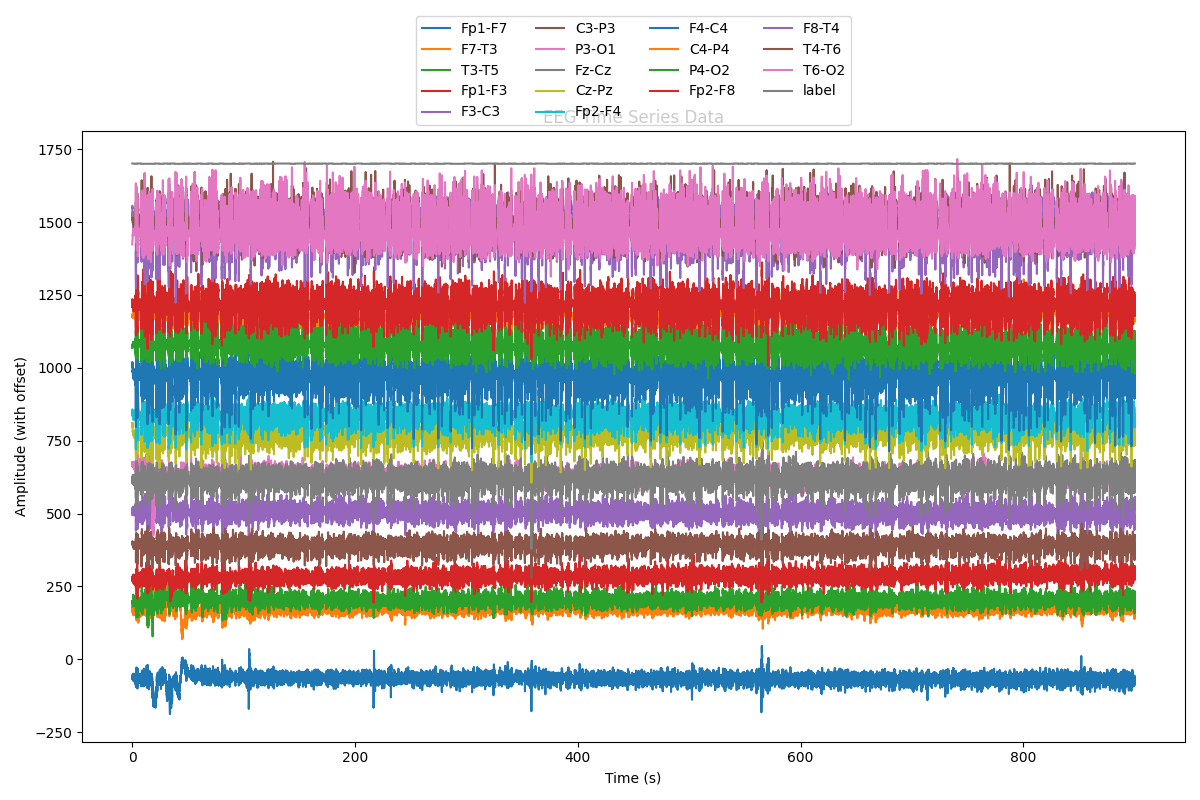

In [ ]:
plot_eeg_multiple(data_learning_labeled)

###  Make predictions

(SKIP THIS FOR NOW STILL WAITING ON GROUND TRUTH LABELS FROM ANNOTATORS)

Dropping 'ground_truth' column from testing datasets

In [ ]:
# data_testing_cropped = data_testing.iloc[eeg_cols]

In [ ]:
eeg_testing = data_testing.copy()#_cropped[eeg_cols]
eeg_testing.head()

,Fp1-F7,F7-T3,T3-T5,Fp1-F3,F3-C3,C3-P3,P3-O1,Fz-Cz,Cz-Pz,Fp2-F4,F4-C4,C4-P4,P4-O2,Fp2-F8,F8-T4,T4-T6,T6-O2
0 days 00:15:00,-67.478592,86.093376,33.828796,-18.435799,137.821014,-75.533073,8.412453,-35.260704,3.400780,-70.521400,24.342415,101.486382,-141.221786,-81.081703,120.101166,43.315174,-168.249023
0 days 00:15:00.003906250,-63.719849,92.000000,33.470818,-15.929962,140.684814,-73.206223,11.813232,-33.112839,7.517509,-68.373543,30.607002,101.486382,-140.863815,-78.575874,123.501938,46.178989,-168.249023
0 days 00:15:00.007812500,-61.035011,100.233459,27.743191,-13.603111,141.937744,-72.132294,15.035019,-32.038910,7.875486,-66.225677,35.260696,100.770432,-140.863815,-77.143967,126.723740,48.326847,-168.964981
0 days 00:15:00.011718750,-60.140076,95.758759,33.470814,-11.992218,140.505844,-71.953308,18.256809,-32.038910,8.770428,-63.898827,33.828789,99.517509,-138.715958,-73.564201,126.902725,47.610893,-170.217896
0 days 00:15:00.015625,-56.739304,93.073929,35.260704,-8.233467,138.357971,-72.848251,20.762646,-31.859922,7.696497,-61.214005,27.206223,99.517509,-134.957199,-69.089493,121.712067,48.505836,-170.575867


In [ ]:
print(eeg_testing.shape)

(14780160, 17)


In [ ]:
labels_predicted = detector.predict(eeg_testing)

In [ ]:
print(len(labels_predicted))

28868


In [ ]:
labels_frame_training = combine_windows_with_labels(detector.clean_windows(detector.get_windows(eeg_testing)), labels_predicted)
data_testing_labeled = data_testing.copy()
data_testing_labeled['label'] = labels_frame_training['label']

In [ ]:
data_testing_labeled.head()

,Fp1-F7,F7-T3,T3-T5,Fp1-F3,F3-C3,C3-P3,P3-O1,Fz-Cz,Cz-Pz,Fp2-F4,F4-C4,C4-P4,P4-O2,Fp2-F8,F8-T4,T4-T6,T6-O2,label
0 days 00:15:00,-67.478592,86.093376,33.828796,-18.435799,137.821014,-75.533073,8.412453,-35.260704,3.400780,-70.521400,24.342415,101.486382,-141.221786,-81.081703,120.101166,43.315174,-168.249023,0
0 days 00:15:00.003906250,-63.719849,92.000000,33.470818,-15.929962,140.684814,-73.206223,11.813232,-33.112839,7.517509,-68.373543,30.607002,101.486382,-140.863815,-78.575874,123.501938,46.178989,-168.249023,0
0 days 00:15:00.007812500,-61.035011,100.233459,27.743191,-13.603111,141.937744,-72.132294,15.035019,-32.038910,7.875486,-66.225677,35.260696,100.770432,-140.863815,-77.143967,126.723740,48.326847,-168.964981,0
0 days 00:15:00.011718750,-60.140076,95.758759,33.470814,-11.992218,140.505844,-71.953308,18.256809,-32.038910,8.770428,-63.898827,33.828789,99.517509,-138.715958,-73.564201,126.902725,47.610893,-170.217896,0
0 days 00:15:00.015625,-56.739304,93.073929,35.260704,-8.233467,138.357971,-72.848251,20.762646,-31.859922,7.696497,-61.214005,27.206223,99.517509,-134.957199,-69.089493,121.712067,48.505836,-170.575867,0


In [ ]:
plot_eeg_multiple(data_testing_labeled)

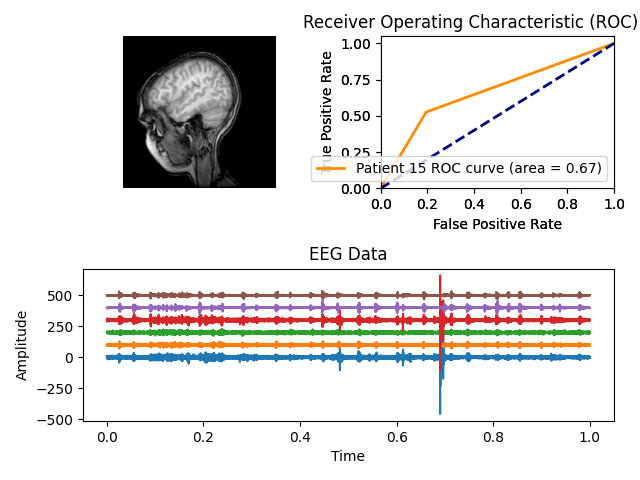

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cbook as cbook
import matplotlib.cm as cm

from matplotlib.collections import LineCollection
from matplotlib.ticker import MultipleLocator

from sklearn.metrics import roc_curve, roc_auc_score

fig = plt.figure("MRI_ROC_EEG")

# Load the MRI data (256x256 16 bit integers)
with cbook.get_sample_data('s1045.ima.gz') as dfile:
    im = np.frombuffer(dfile.read(), np.uint16).reshape((256, 256))

# Plot the MRI image
ax0 = fig.add_subplot(2, 2, 1)
ax0.imshow(im, cmap=cm.gray)
ax0.axis('off')

## Plot the histogram of MRI intensity
#ax1 = fig.add_subplot(2, 2, 2)
#im = np.ravel(im)
#im = im[np.nonzero(im)]  # Ignore the background
#im = im / (2**16 - 1)  # Normalize
#ax1.hist(im, bins=100)
#ax1.xaxis.set_major_locator(MultipleLocator(0.4))
#ax1.minorticks_on()
#ax1.set_yticks([])
#ax1.set_xlabel('Intensity (a.u.)')
#ax1.set_ylabel('MRI density')


# calculate specificity and sensitivity for patient 15
true_labels = data_testing_cropped_labeled['ground_truth']  # ground truth labels
predicted_scores = data_testing_cropped_labeled['label']  # predicted labels

# Compute ROC curve and ROC area
fpr, tpr, _ = roc_curve(true_labels, predicted_scores)
roc_auc = roc_auc_score(true_labels, predicted_scores)

# Plot ROC curve
ax1 = fig.add_subplot(2, 2, 2)
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'Patient 15 ROC curve (area = {roc_auc:.2f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Receiver Operating Characteristic (ROC) Curve')
ax1.legend(loc="lower right")

# Load the EEG data
n_samples = 180000  # Number of samples from your example data
data = eeg_testing.copy()
data = np.array([float(x) for x in data.iloc[0].values])

# Plot the EEG data
t_s = np.arange(n_samples) / n_samples  # Assuming equal intervals between measurements

ax2 = fig.add_subplot(2, 1, 2)
ax2.set_title('EEG Data')
ax2.set_xlabel('Time')
ax2.set_ylabel('Amplitude')
for i, col in enumerate(eeg_testing.columns):
    x = eeg_testing[col].to_numpy()
    plt.plot(t_s, x+100*i)

# Adjust layout
fig.tight_layout()

plt.show()

In [ ]:
data_testing_cropped_labeled['ground_truth'].shape


(180000,)

In [ ]:
data_testing_cropped_labeled['label'].shape


(180000,)

#### Calculate Specificity and Sensitivity

In [ ]:
from sklearn.metrics import confusion_matrix

# calculate specificity and sensitivity for patient 15
true_labels = data_testing_cropped_labeled['ground_truth']  # ground truth labels
predicted_scores = data_testing_cropped_labeled['label']  # predicted labels

confusion_matrix = np.array(confusion_matrix(true_labels, predicted_scores))

TP = np.array(np.diag(confusion_matrix))
FP = np.sum(confusion_matrix, axis=0) - TP
FN = confusion_matrix.sum(axis=1) - TP
TN = np.sum(confusion_matrix)# - (FP + FN + TP)

specificity = confusion_matrix[0, 0] / (confusion_matrix[0, 0] + confusion_matrix[0, 1])
sensitivity = confusion_matrix[1, 1] / (confusion_matrix[1, 0] + confusion_matrix[1, 1])

print(f"TP: {TP}")
print(f"FP: {FP}")
print(f"FN: {FN}")
print(f"TN: {TN}")
print(confusion_matrix)
print(f"Specificity: {specificity:.2f}")
print(f"Sensitivity: {sensitivity:.2f}")


TP: [144782     20]
FP: [   18 35180]
FN: [35180    18]
TN: 180000
[[144782  35180]
 [    18     20]]
Specificity: 0.80
Sensitivity: 0.53


#### Calculate Burst Per Minute (BPM)


##### Calculate Mean Absolute Error (MAE) of BPM

### Calculate AUROC 

In [ ]:
fpr = 1 - specificity
tpr = sensitivity
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)

In [ ]:
# calculate auroc for patient 15
from sklearn.metrics import auc, roc_curve

fpr, tpr, _ = roc_curve(true_labels, scores)
auroc = auc(fpr, tpr)
print(f"AUROC: {auroc:.2f}")
                                                               

AUROC: 0.67


#### Plot ROC and AUROC Curves

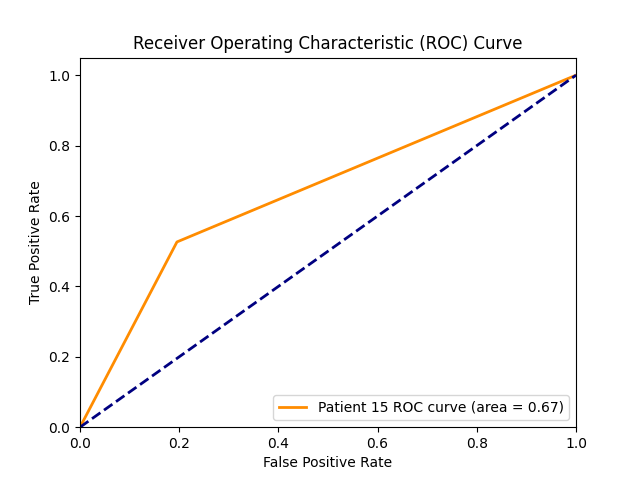

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# calculate specificity and sensitivity for patient 15
true_labels = data_testing_cropped_labeled['ground_truth']  # ground truth labels
predicted_scores = data_testing_cropped_labeled['label']  # predicted labels

# Compute ROC curve and ROC area
fpr, tpr, _ = roc_curve(true_labels, predicted_scores)
roc_auc = roc_auc_score(true_labels, predicted_scores)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Patient 15 ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()